# Reference Star Optical-IR Color Estimation


## Imports
* _numpy_ for math
* _matplotlib_ for plotting
* _urllib_ for URL access

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import urllib

## Introduction
This notebook estimates the 2MASS Ks-band near-IR magnitude of a reference star from its
SDSS r- and i-band optical magnitudes and extinction. It uses a database of stellar 
colors generated by the TRILEGAL stellar population synthesis code (Girardi, L. et al. 2005, A&A, 436, 895) for Av = 0.0, 0.1..., 4.9, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0. The user may consider running additional models at http://stev.oapd.inaf.it/cgi-bin/trilegal to extend this database. Extinction (Av) can be specified by the user or looked up for the source position (RA, Dec) using the NASA/IPAC Extragalactic Database. This Av value is rounded to the nearest tenth for Av <= 5 and the nearest integer for Av > 5.

## Functions to Retrieve Target Info (RA, Dec, Extinction)

In [2]:
def urlname(name):
        """Make object name suitable for URL query"""
        urlname=name.replace('+','%2B')
        urln=urlname.replace(' ','+')
        return urln
    
def nedbyname(name):
        """Get NED Preferred Basic Data (RA, Dec, Type, Redshift) """
        urln=urlname(name)
        url='http://ned.ipac.caltech.edu/cgi-bin/objsearch?objname='+urln+'&extend=no&out_csys=Equatorial&out_equinox=J2000.0&of=ascii_bar'
        #print(url)
        response = urllib.request.urlopen(url)
        neddata = response.read().decode('utf-8')
        datalines=neddata.split('\n')
        basicdataline=datalines[25]
        cols=basicdataline.split('|')
        nedname=cols[1].strip()
        ra=cols[2].strip()
        dec=cols[3].strip()
        #print("RA, Dec:", ra, dec)
        nedpretype=cols[4].strip()
        nedprefz=cols[6].strip()

        return [nedname,ra,dec,nedpretype,nedprefz]
    
def nedextinct(ra,dec):
        """Retrieve Galactic Extinction from NED for [NUV,u,g,r,i,z] at (ra,dec)"""
        radec=ra.strip()+'d&lat='+dec.strip()+'d'
        url="http://ned.ipac.caltech.edu/cgi-bin/calc?in_csys=Equatorial&in_equinox=J2000.0&obs_epoch=2000.0&lon="+radec+"&pa=0.0&out_csys=Equatorial&out_equinox=J2000.0"
        #print(url)
        response = urllib.request.urlopen(url)
        extdata = response.read().decode('utf-8')
        extdatalines=extdata.strip('<tr><td>')
        extdatalines=extdatalines.split('\n')
        #print(extdatalines)
        Bline=extdatalines[76].split()
        Vline=extdatalines[77].split()
        A_v = np.round(float(Vline[3]),decimals=3)
        EBV=float(Bline[3])-float(Vline[3])
        nuvext=np.round(float(EBV)*8.741,decimals=3)   #Wyder_2005_ApJ_619_L15
        extin=[nuvext]
        print('Extinction (mag):')
        print('A(V) = ', A_v)
        print('GALEX NUV', nuvext)
        for j in range(8):
                extcols=extdatalines[j+80].split()
                extband=extcols[0]+' '+extcols[1]
                extval=extcols[3]
                print(extband, extval)
                extin.append(float(extval))
                
        return [A_v,extin]

Limit scrolling in output: 

In [3]:
%%javascript
IPython.OutputArea.auto_scroll_threshold = 9999;

<IPython.core.display.Javascript object>

# Read in Data for Simulated Star Fields
Theoretical Galactic stellar population with slab extinction of Av from TRILEGAL (Girardi, L. et al. 2005, A&A, 436, 895).
* The total field area is 0.1 deg^2 to generate a manageable set of stars for each Av value.
* Photometric system SDSS ugriz + 2MASS JHKs
* Limiting magnitude of J=27.5 mag
* Binaries turned on
* Extinction with calibration at infinity Av(infinity) = 0.0, 0.1, 0.2...5.0, 6.0...10.0

In [4]:
#Read in Trilegal data:
fname='refstar_TRILEGAL.dat'

#Av of simulation
Av_tags=[]
for av_val in list(np.arange(0.0,5.1,0.1)): 
    av_string='0'
    av_string+='%4.2f' % (av_val)
    Av_tags.append(av_string)
Av_tags+=['06.0','07.0','08.0','09.0','10.0']

#Trilegal star colors
tl_Av_tot=[]
tl_Av=[]
tl_u=[]
tl_g=[]
tl_r=[]
tl_i=[]
tl_z=[]
tl_J=[]
tl_H=[]
tl_Ks=[]
tl_rminusi=[]
tl_iminusKs=[]
lct=[]

f=open('refstar_TRILEGAL.dat')
lines=f.readlines()
datalines=lines[1:]

lctr = 0  # -DC
for line in datalines:
    cols= line.split()
    try:
        lctr+=1
        r=float(cols[14])
        i=float(cols[15])
        Ks=float(cols[19])

        tl_Av.append(float(cols[9]))
        tl_u.append(float(cols[12]))
        tl_g.append(float(cols[13]))
        tl_r.append(r)
        tl_i.append(i)
        tl_z.append(float(cols[16]))
        tl_J.append(float(cols[17]))  
        tl_H.append(float(cols[18]))
        tl_Ks.append(Ks)
        tl_rminusi.append(r-i)
        tl_iminusKs.append(i-Ks)
        tl_Av_tot.append(float(cols[0]))
        
    except: pass

f.close()
print(lines[0:2])
print(lctr)

#Total Av array
tl_Avtot_arr=np.array(tl_Av_tot)

#Color and Av arrays
tl_rminusi_arr=np.array(tl_rminusi)
tl_iminusKs_arr=np.array(tl_iminusKs)
tl_Av_arr=np.array(tl_Av)



['#Av_tot Gc logAge [M/H] m_ini   logL   logTe  logg   m-M0  Av_*   m2/m1  mbol   u      g      r      i      z      J      H      Ks    Mact\n', '00.00   1   8.51  0.25  1.63003  0.842 3.862  4.202  9.30  0.000 0.00 11.966 13.072 11.979 11.869 11.925 12.025 11.334 11.238 11.217  1.630 \n']
190411


## TA Reference Star Inputs
Enter the following in the block below:
* Name, or RA and Dec, or Av value to estimate extinction.
* SDSS r- and i-band magnitudes and 1-sigma uncertainties for TA reference star

In [11]:
#Name of science target or TA reference star for Av estimation
#objname='Cygnus A'
objname='none'
#nedlookup=1
nedlookup = False

#RA and Dec of science target or reference star for Av estimation
#ra=''; dec=''
ra = '01:37:25'
dec = '-08:27:25'
from astropy.coordinates import SkyCoord
import astropy.units as u
c = SkyCoord(ra + ' ' + dec, unit=(u.hourangle, u.deg))
fra, fdec = c.ra.value, c.dec.value
ra = '%.7f' % fra
dec = '%.7f' % fdec

#Input SDSS r- and i- band magnitudes of TA reference star
r=20.0; i=19.4
r=25.0; i=23.4  
dr=0.03; di=0.03
Av_inp=3.7

print('RA = ', ra)
print('Dec = ', dec)

RA =  24.3541667
Dec =  -8.4569444


## Estimate Extinction

In [12]:
#NED lookup and extinction
if (nedlookup==1):
    print('Name:', objname)
    try:
        nedbyn=nedbyname(objname)
        ra=nedbyn[1]; dec=nedbyn[2]
    except:
        print("Could not resolve objectname.")
        Av=0.0

#Check for valid RA and Dec
print('RA  = '+ra)
print('Dec = '+dec)

validpos=0
try:
    fra=np.float(ra)
    fdec=np.float(dec)
    if (fra>=0.) and (fra<=360.) and (fdec>=-360.) and (fdec<=360.):
        validpos=1
    else:
        validpos=0
        print('RA or Dec is not valid.')
except:
    print('RA or Dec is not valid.')
    validpos=0

    #NED extinction

#Look up extinction at (RA,Dec) using NED
if validpos==1:
    nedext=nedextinct(ra,dec)
    Av_ned=nedext[0]
    Av=Av_ned
else:
    Av=Av_inp

#Round Av to nearest tenth (or nearest integer for Av > 5)
if Av<=5:
    Av=np.round(Av,decimals=1)
else:
    Av=np.round(Av)

print()
print('Using Av =', Av)

RA  = 24.3541667
Dec = -8.4569444
Extinction (mag):
A(V) =  0.091
GALEX NUV 0.262
SDSS u 0.141
SDSS g 0.110
SDSS r 0.076
SDSS i 0.056
SDSS z 0.042
UKIRT J 0.024
UKIRT H 0.015
UKIRT K 0.010

Using Av = 0.1


## Estimate TA Reference Star i-K Color and K-band magnitude


Total number of model stars with Av = 0.05 - 0.10: 1405
Number of these stars used to estimate i - Ks color: 25


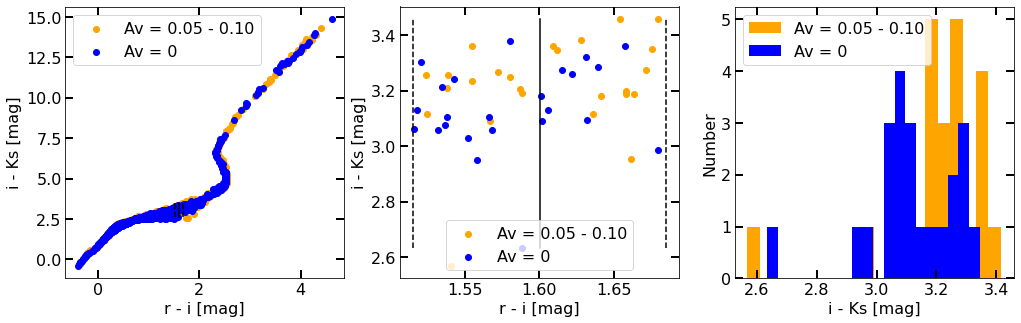

Input: r = 25.00 +/- 0.03,  i = 23.40 +/- 0.03, Av = 0.10 
Result: Ks = [19.94,20.83] at 95% confidence


In [13]:
#Formatted input parameters
sinput='Input: r = %5.2f +/- %4.2f,  i = %5.2f +/- %4.2f, Av = %4.2f ' % (r, dr, i, di, Av)
Avinput='Av = %4.2f ' % (Av)
 
#Color range
rminusi=r-i
drminusi=np.sqrt(dr**2+di**2)
sigcut=2.0
#print(rminusi, drminusi, 5*drminusi)

#Select simulations with correct Av
tl_0=np.where(tl_Avtot_arr==0.0)[0] 
tl_s=np.where(tl_Avtot_arr==Av)[0] 

tl_Avtot_0=tl_Avtot_arr[tl_0]
tl_Av_0= tl_Av_arr[tl_0]
tl_rmi_0=tl_rminusi_arr[tl_0]
tl_imKs_0=tl_iminusKs_arr[tl_0]

tl_Avtot_select=tl_Avtot_arr[tl_s]
tl_Av_select=tl_Av_arr[tl_s]
tl_rmi_select=tl_rminusi_arr[tl_s]
tl_imKs_select=tl_iminusKs_arr[tl_s]

#Av range probed
print()
Avmin=min(tl_Av_select)
Avmax=max(tl_Av_select)
#print('Input:', Avinput)
#print('Sample Av range:', Avmin, Avmax )

Avrange='Av = %4.2f - %4.2f' % (Avmin,Avmax)


#Av=0
tl_subset0=np.where((tl_rmi_0>rminusi-sigcut*drminusi) & (tl_rmi_0<rminusi+sigcut*drminusi))[0]

#Uniform Av=0-Avf
tl_subset=np.where((tl_rmi_select>rminusi-sigcut*drminusi) & (tl_rmi_select<rminusi+sigcut*drminusi))[0]

tl_imKs_0_subset=tl_imKs_0[tl_subset0]
tl_imKs_select_subset=tl_imKs_select[tl_subset]
tl_rmi_0_subset=tl_rmi_0[tl_subset0]
tl_rmi_select_subset=tl_rmi_select[tl_subset]

imk0_0=min(tl_imKs_0_subset)
imkf_0=max(tl_imKs_0_subset)
nbins_0=21
dimk_0=(imkf_0-imk0_0)/nbins_0
imkbins_0=[imk0_0+binnum*dimk_0 for binnum in range(nbins_0)]

imk0=min(tl_imKs_select_subset)
imkf=max(tl_imKs_select_subset)
nbins=21
dimk=(imkf-imk0)/nbins
imkbins=[imk0+binnum*dimk for binnum in range(nbins)]

#Figure
print('Total number of model stars with '+Avrange+':', len(tl_s))
print('Number of these stars used to estimate i - Ks color:', len(tl_subset))

f,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(17, 5))
ax1.scatter(tl_rmi_select,tl_imKs_select,label=Avrange,c='orange')
ax1.scatter(tl_rmi_0,tl_imKs_0,label="Av = 0",c='b')

fs=16  # font size
ax1.plot([rminusi,rminusi], [imk0_0,imkf], c='k')
ax1.plot([rminusi-sigcut*drminusi,rminusi-sigcut*drminusi], [imk0_0,imkf],linestyle='--', c='k')
ax1.plot([rminusi+sigcut*drminusi,rminusi+sigcut*drminusi], [imk0_0,imkf], linestyle='--', c='k')
ax1.set_xlabel('r - i [mag]',fontsize=fs)
ax1.set_ylabel('i - Ks [mag]',fontsize=fs)
ax1.legend(fontsize=fs)
ax1.tick_params(axis='both', which='major', labelsize=fs, length=8, width=2, direction='in', top=True, right=True)

ax2.scatter(tl_rmi_select_subset,tl_imKs_select_subset, label=Avrange, c='orange')
ax2.scatter(tl_rmi_0_subset,tl_imKs_0_subset, label='Av = 0',c='b')
ax2.plot([rminusi,rminusi], [imk0_0,imkf], c='k')
ax2.plot([rminusi-sigcut*drminusi,rminusi-sigcut*drminusi], [imk0_0,imkf],linestyle='--', c='k')
ax2.plot([rminusi+sigcut*drminusi,rminusi+sigcut*drminusi], [imk0_0,imkf], linestyle='--', c='k')
ax2.set_xlabel('r - i [mag]',fontsize=fs)
ax2.set_ylabel('i - Ks [mag]',fontsize=fs)
ax2.legend(fontsize=fs)
ax2.tick_params(axis='both', which='major', labelsize=fs, length=8, width=2, direction='in', top=True, right=True)

ax3.hist(tl_imKs_select_subset,bins=imkbins,range=(-1,1),label=Avrange,color='orange')
ax3.hist(tl_imKs_0_subset,bins=imkbins_0,range=(-1,1),label='Av = 0', color='blue')
ax3.set_xlabel('i - Ks [mag]',fontsize=fs)
ax3.set_ylabel('Number',fontsize=fs)
ax3.legend(fontsize=fs)
ax3.tick_params(axis='both', which='major', labelsize=fs, length=8, width=2, direction='in', top=True, right=True)

plt.show()

ks0=i-imkf
ksf=i-imk0  #i=i-imk0_0 for Av=0
simk0='%5.2f' % (ks0)
simkf='%5.2f' % (ksf)
print(sinput)
print('Result: Ks = ['+simk0+','+simkf+'] at 95% confidence')

<img style="float: right;" 
src="https://raw.githubusercontent.com/spacetelescope/notebooks/master/assets/stsci_pri_combo_mark_horizonal_white_
bkgd.png" alt="Space Telescope Logo" width="200px"/>

Notebook created by Patrick Ogle, Leonardo Ubeda, and Alaina Henry.